In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_predicted(true_y: dict[str, float], predicted_y: dict[str, ModelPrediction]):

    points_x = []
    points_y = []
    for query_id, true_latency in true_y.items():
        points_x.append(true_latency)
        points_y.append(predicted_y[query_id].overall_mean_s())

    plt.scatter(points_x, points_y)
    plt.xlabel("True Latency (s)")
    plt.ylabel("Predicted Latency (s)")
    plt.title("True vs Predicted Query Latencies")
    plt.xscale("log")
    plt.yscale("log")
    plt.plot([0, max(points_x)], [0, max(points_x)], color='red', linestyle='--')  # Diagonal line
    plt.show()

In [1]:
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.models.iconq_model import IconqModel
from autoslo.models.model_prediction import ModelPrediction
from autoslo.workload_execution.trace import Trace

ICONQ_MODEL_ID = "1767629626"
TRACE_RUN_ID = "1763941019"


model = IconqModel.load(
    model_id=ICONQ_MODEL_ID,
)

trace = Trace(TRACE_RUN_ID)
query_timeline = QueryTimeline(model._iconq_query_featurizer, model._iconq_interaction_featurizer)  # type: ignore[attr-defined]
query_timeline.initialize_from_trace(trace, stage_model=model._stage_model)  # type: ignore[attr-defined]

predictions = model.predict_from_query_timeline(query_timeline)

assert predictions, "Expected predictions for at least one query"
timeline_query_ids = set(query_timeline.query_ids)
assert set(predictions).issubset(timeline_query_ids)

sample_prediction = next(iter(predictions.values()))
assert isinstance(sample_prediction, ModelPrediction)
#assert sample_prediction.overall_mean_s() > 0   

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767629626/model_1767630653.pth


  0%|          | 0/1 [00:00<?, ?it/s]

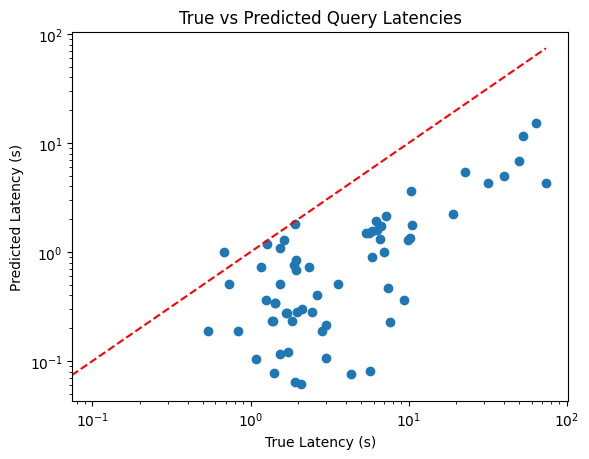

In [3]:
true_y = trace.latencies_s
predicted_y = predictions
plot_true_predicted(true_y, predicted_y)


In [ ]:
from autoslo.nn.concurrent_query_dataset import ConcurrentQueryDataset
import os

dataset = ConcurrentQueryDataset.load_from(
    os.path.join(model._save_dir, "dataset.pkl")
)

In [58]:
from torch.utils.data import DataLoader, Subset
import torch
train_config  = model._train_config_sequence[-1]
train_idxs, val_idxs, test_idxs = model._get_data_splits(
    len(dataset), train_config
)
train_dataset = Subset(dataset, train_idxs)
val_dataset = Subset(dataset, val_idxs)
train_generator = torch.Generator()
train_generator.manual_seed(
    train_config.training_dataloader_shuffle_seed
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=train_config.batch_size,
    shuffle=True,
    generator=train_generator,
    collate_fn=ConcurrentQueryDataset.collate_and_pad,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=train_config.batch_size,
    shuffle=False,
    collate_fn=ConcurrentQueryDataset.collate_and_pad,
)

In [59]:
import pandas as pd
regenerated_query_id_hashes = set()
for batch in val_dataloader:
    _, _, _, _, query_id_hashes = batch
    regenerated_query_id_hashes.update([t.item() for t in query_id_hashes])

path = "/home/markakis/chunkbench/data/iconq_models/1767524004/val_predictions_10.csv"
val_predictions_df = pd.read_csv(path)
val_prediction_query_id_hashes = set(val_predictions_df["query_uuid"].tolist())
assert regenerated_query_id_hashes == val_prediction_query_id_hashes

In [60]:
val_predictions_df['y_pred_mean'] = val_predictions_df['y_pred'].apply(
    lambda x: float(x[x.find('[')+1 : x.find(']')])
)

In [61]:
val_predictions_df

,Unnamed: 0,query_uuid,y,y_pred,abs_error,q_error,percentile_at_true_latency,y_pred_mean
0,578,3488603667,3600.013400,"ModelPrediction(mean_s=array([3056.3413], dtyp...",543.672100,1.177883,1.0,3056.341300
1,72,3575392289,3600.010000,"ModelPrediction(mean_s=array([3008.2844], dtyp...",591.725600,1.196699,1.0,3008.284400
2,257,1684989432,3600.010000,"ModelPrediction(mean_s=array([3170.244], dtype...",429.766100,1.135562,1.0,3170.244000
3,963,375452724,3600.010000,"ModelPrediction(mean_s=array([3137.189], dtype...",462.821040,1.147527,1.0,3137.189000
4,130,2948633518,3600.010000,"ModelPrediction(mean_s=array([3119.7239], dtyp...",480.286130,1.153952,1.0,3119.723900
...,...,...,...,...,...,...,...,...
964,93,3931910140,0.141785,"ModelPrediction(mean_s=array([0.40748602], dty...",0.265701,2.873973,0.0,0.407486
965,792,1389041158,0.140791,"ModelPrediction(mean_s=array([0.60445607], dty...",0.463665,4.293288,0.0,0.604456
966,471,1682474248,0.131138,"ModelPrediction(mean_s=array([0.5651915], dtyp...",0.434053,4.309896,0.0,0.565191
967,639,2594822939,0.125033,"ModelPrediction(mean_s=array([0.48171645], dty...",0.356684,3.852718,0.0,0.481716


In [62]:
from tqdm import tqdm
predictions: dict[str, ModelPrediction] = {}



model._nn.eval()
with torch.no_grad():
    for x, x_len, pinch_points, _, query_id_hashes in tqdm(val_dataloader):
        x, x_len, pinch_points = (
            x.to(model._device),
            x_len.to(model._device),
            pinch_points.to(model._device),
        )

        y_pred_mean, y_pred_logvar, y_pred_mix = model._nn(
            x,
            x_len,
            pinch_points,
            mdn_mix_softmax_temperature=1.0,
        )

        if model._trained_on_log_runtime:
            y_pred_mean = torch.expm1(y_pred_mean)

        batch_size = x.size(0)
        for i in range(batch_size):
            query_id_hash = query_id_hashes[i].item()
            if model._nn_args["is_mdn"]:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[
                        float(it) for it in y_pred_mean[i].tolist()
                    ],
                    std_dev_s=[
                        float(it)
                        for it in torch.exp(
                            y_pred_logvar[i] / 2
                        ).tolist()
                    ],
                    mix_coeffs=[
                        float(it) for it in y_pred_mix[i].tolist()
                    ],
                )
            elif model._nn_args["is_bayesian"]:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[float(y_pred_mean[i].item())],
                    std_dev_s=[
                        float(torch.exp(y_pred_logvar[i] / 2).item())
                    ],
                )
            else:
                predictions[query_id_hash] = ModelPrediction(
                    mean_s=[float(y_pred_mean[i].item())],
                )

val_predictions_df['y_pred_mean_new'] = val_predictions_df['query_uuid'].apply(
    lambda qid: predictions[qid].overall_mean_s()
)

  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:02<00:00, 12.17it/s]


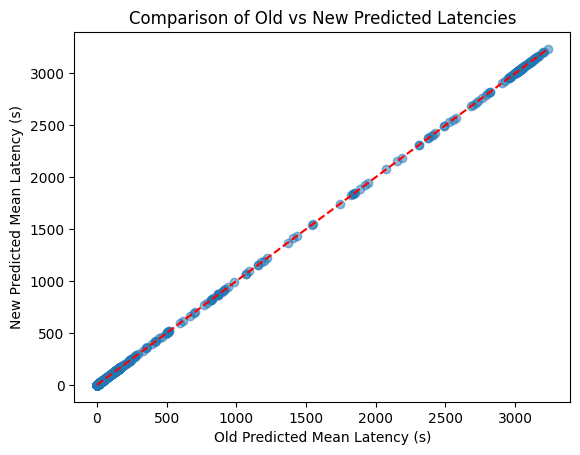

In [63]:
fig, ax = plt.subplots()
ax.scatter(
    val_predictions_df['y_pred_mean'],
    val_predictions_df['y_pred_mean_new'],
    alpha=0.5
)
ax.set_xlabel("Old Predicted Mean Latency (s)")
ax.set_ylabel("New Predicted Mean Latency (s)")
ax.set_title("Comparison of Old vs New Predicted Latencies")
plt.plot([0, max(val_predictions_df['y_pred_mean'])], [0, max(val_predictions_df['y_pred_mean'])], color='red', linestyle='--')  # Diagonal line
plt.show()

In [3]:
import os 
import autoslo.utils.paths as pu
import yaml
from train import find_run_ids, set_up_featurizer
from autoslo.featurization.iconq_query_featurizer import IconqQueryFeaturizer


progress_cache_path = os.path.join(
        pu.AUTOSLO_ROOT,
        "experiments",
        "06_iconq_training",
        "progress_cache.yml",
    )

cached_progress = {}

if os.path.exists(progress_cache_path):
    with open(progress_cache_path, "r") as f:
        cached_progress = yaml.safe_load(f)

print("Step 1: Finding run IDs...")
if "run_ids" not in cached_progress:
    print("\tRun IDs not cached. Computing...")
    run_ids = find_run_ids()
    cached_progress["run_ids"] = run_ids
    with open(progress_cache_path, "w") as f:
        yaml.safe_dump(cached_progress, f)
else:
    print("\tUsing cached run IDs.")
    run_ids = cached_progress["run_ids"]

featurizer = IconqQueryFeaturizer(schema_name="tpcds1000", run_ids=run_ids)

Step 1: Finding run IDs...
	Using cached run IDs.
Loading query plans...


  0%|          | 0/65 [00:00<?, ?it/s]

Finding top operators...


  0%|          | 0/9687 [00:00<?, ?it/s]

Top 15 operators cover 279418/326882 = 85.48% of all operator occurrences.
Top operators:
  0: XN Seq Scan
  1: XN Hash
  2: XN Hash Join DS_DIST_ALL_NONE
  3: XN HashAggregate
  4: XN Network
  5: XN Hash Join DS_BCAST_INNER
  6: XN Subquery Scan
  7: XN Sort
  8: XN Result
  9: XN Merge
  10: XN Hash Join DS_DIST_OUTER
  11: XN Limit
  12: XN Append
  13: XN Hash Join DS_DIST_INNER
  14: XN Aggregate
Finding top tables...
Top 20 tables by size:
  store_sales: 2879987999 rows
  catalog_sales: 1439980416 rows
  inventory: 783000000 rows
  web_sales: 720000376 rows
  store_returns: 287999764 rows
  catalog_returns: 143996756 rows
  web_returns: 71997522 rows
  customer: 12000000 rows
  customer_address: 6000000 rows
  customer_demographics: 1920800 rows
  item: 300000 rows
  time_dim: 86400 rows
  date_dim: 73049 rows
  catalog_page: 30000 rows
  household_demographics: 7200 rows
  web_page: 3000 rows
  promotion: 1500 rows
  store: 1002 rows
  reason: 65 rows
  web_site: 54 rows
Featur

  0%|          | 0/65 [00:00<?, ?it/s]

In [5]:
# Are the last 20 elements of the featurizations always zero?

for featurization in featurizer._featurization_cache.values():
    print(featurization[-20:])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [28]:
from autoslo.workload_execution.trace import Trace

run_id = featurizer._run_ids[0]
trace = Trace(run_id)

tpcds_temp_and_q_idxs = trace.tpcds_temp_and_q_idxs
plans = trace.query_plans()

In [30]:
query_id, tpcds_temp_and_q_idx = next(tpcds_temp_and_q_idxs.items())
plans[query_id]

{'plain_content': [],
 'plan_parameters': {'op_name': 'XN Aggregate',
  'est_startup_cost': 2132819023505.37,
  'est_cost': 2132819023505.37,
  'est_card': 1.0,
  'est_width': 0.0,
  'act_children_card': 1.0,
  'est_children_card': 20449614.0},
 'children': [{'plain_content': [],
   'plan_parameters': {'op_name': 'XN Subquery Scan',
    'est_startup_cost': 2132816722923.8,
    'est_cost': 2132818972381.33,
    'est_card': 20449614.0,
    'est_width': 0.0,
    'act_children_card': 1.0,
    'est_children_card': 20449614.0},
   'children': [{'plain_content': [],
     'plan_parameters': {'op_name': 'XN SetOp Except',
      'est_startup_cost': 2132816722923.8,
      'est_cost': 2132818767885.19,
      'est_card': 20449614.0,
      'est_width': 22.0,
      'act_children_card': 1.0,
      'est_children_card': 204496139.0},
     'children': [{'plain_content': [],
       'plan_parameters': {'op_name': 'XN Sort',
        'est_startup_cost': 2132816722923.8,
        'est_cost': 2132817234164.15,


In [31]:
featurizer._top_operators

['XN Seq Scan',
 'XN Hash',
 'XN Hash Join DS_DIST_ALL_NONE',
 'XN HashAggregate',
 'XN Network',
 'XN Hash Join DS_BCAST_INNER',
 'XN Subquery Scan',
 'XN Sort',
 'XN Result',
 'XN Merge',
 'XN Hash Join DS_DIST_OUTER',
 'XN Limit',
 'XN Append',
 'XN Hash Join DS_DIST_INNER',
 'XN Aggregate']

In [32]:
tpcds_temp_and_q_idx

'087_003'

In [33]:
featurizer.featurize_plan(plans[query_id])[-20:]

[23.777909736188132,
 23.15880798156276,
 0.0,
 22.474203844987404,
 0.0,
 0.0,
 0.0,
 20.490071949778713,
 0.0,
 0.0,
 0.0,
 0.0,
 9.021598248587035,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [29]:
path = '/home/markakis/chunkbench/data/parsed_query_plans/ext_tpcds1000.yml'

ops = set()
with open(path, 'r') as f:
    for row in f.readlines():
        if 'op_name' in row:
            op_name = row.strip().split(': ')[1]
            ops.add(op_name)
ops

{'XN Aggregate',
 'XN Append',
 'XN Hash',
 'XN Hash Full Join DS_DIST_BOTH',
 'XN Hash Full Join DS_DIST_NONE',
 'XN Hash IN Join DS_BCAST_INNER',
 'XN Hash IN Join DS_DIST_ALL_INNER',
 'XN Hash IN Join DS_DIST_ALL_NONE',
 'XN Hash IN Join DS_DIST_INNER',
 'XN Hash Intersect Distinct DS_DIST_NONE',
 'XN Hash Join',
 'XN Hash Join DS_BCAST_INNER',
 'XN Hash Join DS_DIST_ALL_NONE',
 'XN Hash Join DS_DIST_BOTH',
 'XN Hash Join DS_DIST_INNER',
 'XN Hash Join DS_DIST_NONE',
 'XN Hash Join DS_DIST_OUTER',
 'XN Hash Left Join DS_BCAST_INNER',
 'XN Hash Left Join DS_DIST_ALL_NONE',
 'XN Hash Left Join DS_DIST_BOTH',
 'XN Hash Left Join DS_DIST_INNER',
 'XN Hash Left Join DS_DIST_NONE',
 'XN Hash Left Join DS_DIST_OUTER',
 'XN Hash NOT IN Join DS_DIST_NONE',
 'XN Hash Right Join DS_DIST_NONE',
 'XN HashAggregate',
 'XN Limit',
 'XN Materialize',
 'XN Merge',
 'XN Multi Scan',
 'XN Nested Loop DS_BCAST_INNER',
 'XN Network',
 'XN Result',
 'XN Seq',
 'XN Seq Scan',
 'XN SetOp Except',
 'XN Sort